Simple for loop implementation for Mandelbrot

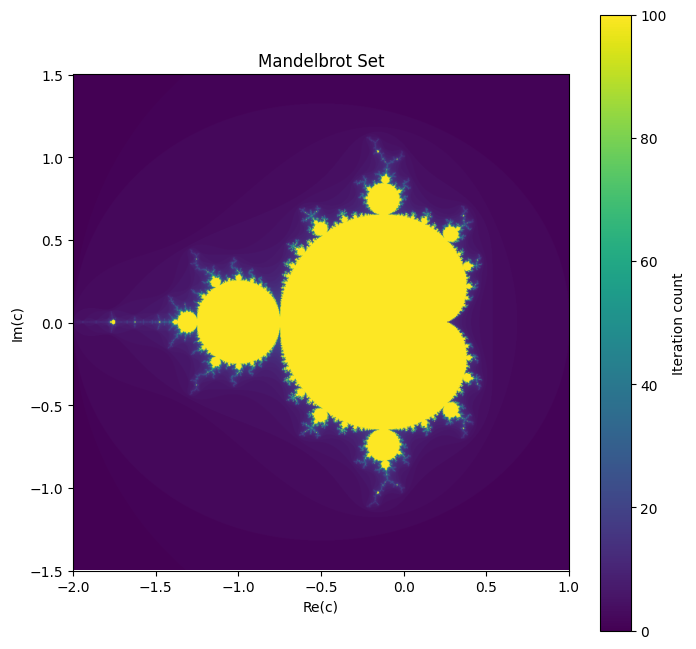

6.56 s ± 131 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define region: 𝑥 ∈ [−2,1],  𝑦 ∈[−1.5,1.5]
# Typical: 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟 =100, resolution: 1024×1024 or large
xmin, xmax = -2, 1
ymin, ymax = -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

# 2. Create grid of complex numbers 𝑐 over this region
x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)

# empty array for unit storage
iterations = np.zeros((height, width), dtype=int)

def mandlebrot_for_loop(x_values, y_values, iterations, plot = False):
    height, width = iterations.shape
    for i in range(height):
        for j in range(width):
            
            # 3. For each point c in grid:
            # note to self: 1j is imaginary unit in python
            c = x_values[j] + 1j * y_values[i]
            
            # > Initialize 𝑧0 =0
            z = 0
            
            # > For 𝑛=0 to 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟:
            for n in range(max_iter):
                
                # > Compute 𝑧𝑛+1 =𝑧𝑛2 +𝑐
                z = z**2 + c
                
                # > If 𝑧𝑛+1 >2: Point escapes! Store 𝑛, break to next point
                if abs(z) > 2:
                    iterations[i, j] = n
                    break
            else:
                # > If loop completes: Point is in set, store 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟
                iterations[i, j] = max_iter
                
    # 5. Visualize with colormap
    if plot:
        plt.figure(figsize=(8, 8))
        plt.imshow(iterations, extent=[xmin, xmax, ymin, ymax], origin='lower')
        plt.colorbar(label="Iteration count")
        plt.title("Mandelbrot Set")
        plt.xlabel("Re(c)")
        plt.ylabel("Im(c)")
        plt.show()
    
    # 4. Return 2D array of iteration counts
    return iterations

        
mandlebrot_for_loop(x_values, y_values, iterations, True)
        
%timeit mandlebrot_for_loop(x_values, y_values, iterations)

Vectorized function

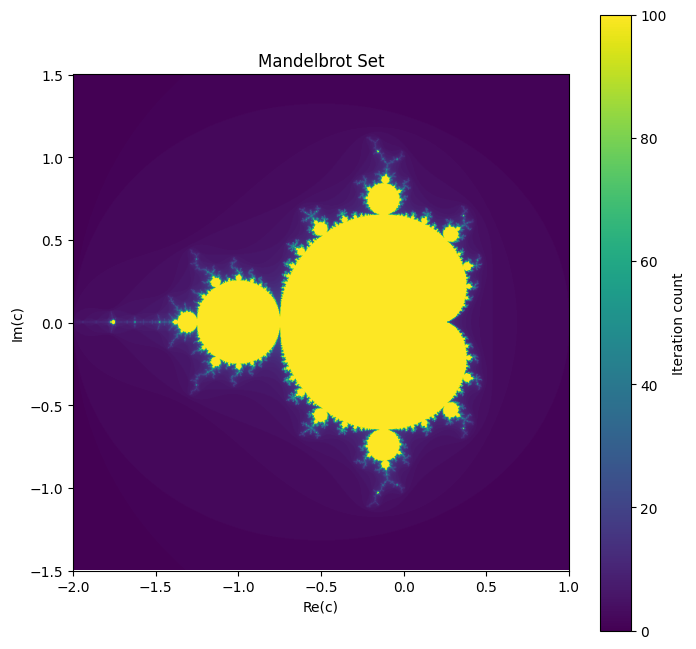

735 ms ± 44.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define region: 𝑥 ∈ [−2,1],  𝑦 ∈[−1.5,1.5]
# Typical: 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟 =100, resolution: 1024×1024 or large
xmin, xmax = -2, 1
ymin, ymax = -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

# 2. Create grid of complex numbers 𝑐 over this region
x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)

# empty array for unit storage
iterations = np.zeros((height, width), dtype=int)

def mandlebrot_for_vectorized(x_values, y_values, iterations, plot = False):

    # 3. For each point c in grid (perform operation on each element in array):
    # note to self: 1j is imaginary unit in python
    c = x_values[None, :] + 1j * y_values[:, None]
    
    # > Initialize 𝑧0 = 0 (for all points) (complex256 to prevent overflow of z)
    z = np.zeros_like(c)
    
    # mask to keep track on updated indexes
    mask = np.ones(c.shape, dtype=bool)
    
    # > For 𝑛=0 to 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟:
    for n in range(max_iter):
        
        # > Compute 𝑧𝑛+1 =𝑧𝑛2 +𝑐
        z[mask] = z[mask]**2 + c[mask]
        
        # > If 𝑧𝑛+1 >2: Point escapes! Store 𝑛 
        escaped = np.abs(z) > 2
        newly_escaped = escaped & mask
        iterations[newly_escaped] = n
        mask[newly_escaped] = False
        
    # > If loop completes: Point is in set, store 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟
    iterations[mask] = max_iter
    
    # 5. Visualize with colormap
    if plot:
        plt.figure(figsize=(8, 8))
        plt.imshow(iterations, extent=[xmin, xmax, ymin, ymax], origin='lower')
        plt.colorbar(label="Iteration count")
        plt.title("Mandelbrot Set")
        plt.xlabel("Re(c)")
        plt.ylabel("Im(c)")
        plt.show()
    
    # 4. Return 2D array of iteration counts
    return iterations

mandlebrot_for_vectorized(x_values, y_values, iterations, True)
        
%timeit mandlebrot_for_vectorized(x_values, y_values, iterations)